## importing library

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#matplotlib inline

## read the dataset

In [21]:
df=pd.read_csv('../Data/height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

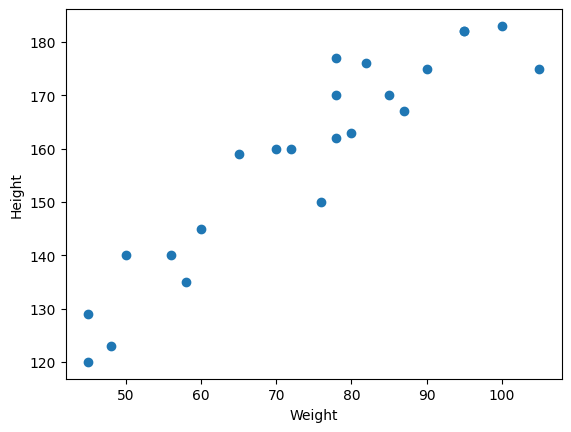

In [22]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')

## div into indep and dep

In [23]:
x=df[['Weight']]
y=df['Height']

## train test split

In [24]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)


## standardize dataset

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test =scaler.tranform(x_test )

array([[ 1.73689094],
       [-0.92026952],
       [ 1.4542143 ],
       [ 0.21043706],
       [-1.48562281],
       [ 1.17153765],
       [-1.6552288 ],
       [-0.80719886],
       [-0.24184557],
       [ 0.0973664 ],
       [-1.37255215],
       [-1.03334018],
       [-0.12877492],
       [ 0.88886101],
       [ 0.43657837],
       [ 0.60618436],
       [ 0.71925502],
       [ 0.32350772]])

## linear regression

In [26]:
from sklearn.linear_model import LinearRegression

regressor=LinearRegression()

regressor.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [28]:
print('the slope or coeff is :', regressor.coef_)
print('the intercept is : ', regressor.intercept_)

the slope or coeff is : [0.9630459]
the intercept is :  85.96709053063559


## ploting line

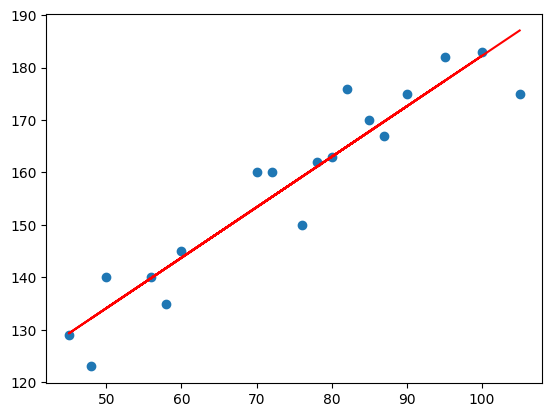

In [29]:
plt.scatter(x_train,y_train)
plt.plot(x_train,regressor.predict(x_train),color='red')

## prediction on test data

In [30]:
y_pred_test=regressor.predict(x_test)

y_pred_test,y_test

(array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
        148.56507414]),
 15    177
 9     170
 0     120
 8     182
 17    159
 Name: Height, dtype: int64)

## plot for test data

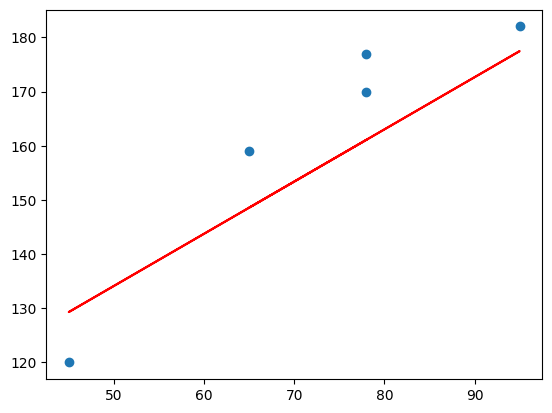

In [31]:
plt.scatter(x_test,y_test)
plt.plot(x_test,regressor.predict(x_test),'r')

## performance metrics

In [34]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

mse=mean_squared_error(y_test,y_pred_test)
mae=mean_absolute_error(y_test,y_pred_test)
rmse=np.sqrt(mse)
score=r2_score(y_test,y_pred_test)
print(mse)
print(mae)
print(rmse)
print(score)

109.77592599051658
9.822657814519232
10.477400726827078
0.776986986042344


### testing on nw data point

In [35]:
scaled_weight= scaler.transform([[80]])
scaled_weight

/Users/ali/Desktop/Machine-Learning/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.32350772]])

In [38]:
scaled_weight[0]

array([0.32350772])

In [37]:
print(regressor.predict([scaled_weight[0]]))

[86.27864331]


/Users/ali/Desktop/Machine-Learning/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## asumption
### plot a scatter plot for the prediction

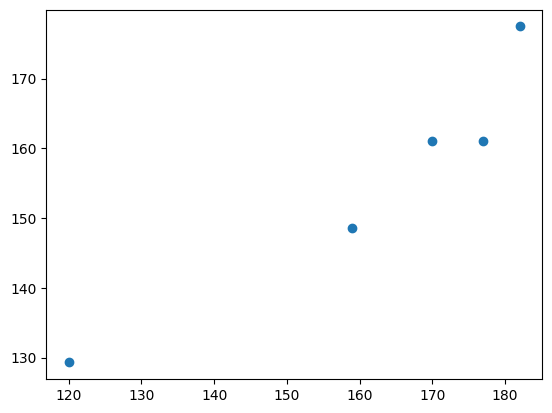

In [40]:
plt.scatter(y_test,y_pred_test)

In [42]:
## residuals

residuals=y_test-y_pred_test

residuals

15    15.915329
9      8.915329
0     -9.304156
8      4.543549
17    10.434926
Name: Height, dtype: float64

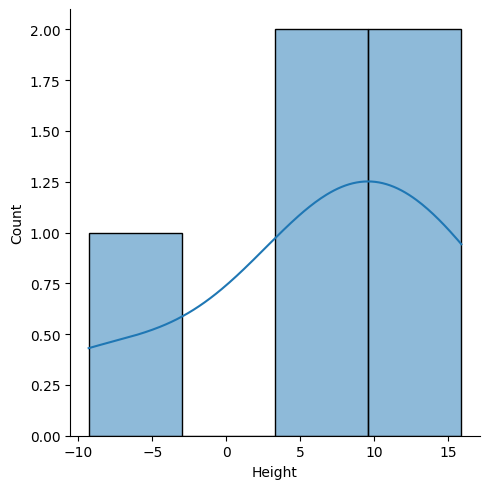

In [43]:
## plot this residual
import seaborn as sns
sns.displot(residuals,kde=True)

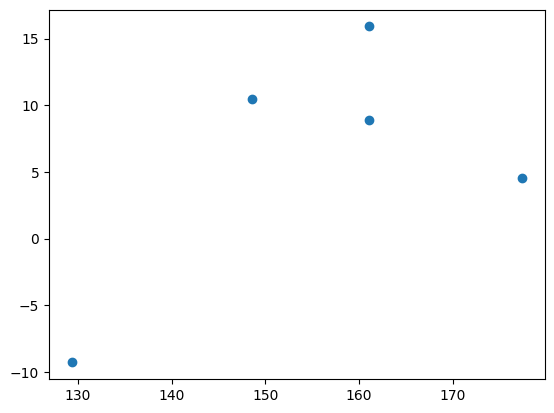

In [44]:
## scatter plot with respect to prediction and residuals
## uniform distribution

plt.scatter(y_pred_test,residuals)